# 04 - Leakage Detection
**DNA Gene Mapping Project - ML Phase V5 - Feature Selection**  
**Author:** Sharique Mohammad  
**Date:** February 2026

## Purpose
Identify and flag all columns that would cause target leakage:
1. Label-derived string columns (clinical_significance_simple, clinvar_pathogenicity_class, etc.)
2. Aggregated priority/tier columns computed from the target
3. Columns with suspiciously high target correlation (above 0.98)

This is the most important step. A leaked feature can inflate F1 to 0.99+ but
the model would fail completely on real unseen data.

## Output
`data/feature_selection/04_leakage_flags.csv`
  - use_case, table, column, leakage_reason, leakage_type, action

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from pathlib import Path
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

PROJECT_ROOT = Path().absolute().parent.parent
FS_DIR       = PROJECT_ROOT / 'data' / 'feature_selection'
FS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Setup complete")
print(f"Feature selection dir: {FS_DIR}")

Setup complete
Feature selection dir: C:\Users\Sharique\Desktop\Self_Project\GitHub_Project\genomic-variant-data-science-pipeline\data\feature_selection


## 2. Database Connection

In [2]:
POSTGRES_HOST     = os.getenv("POSTGRES_HOST")
POSTGRES_PORT     = os.getenv("POSTGRES_PORT")
POSTGRES_DB       = os.getenv("POSTGRES_DB")
POSTGRES_USER     = os.getenv("POSTGRES_USER")
POSTGRES_PASSWORD = os.getenv("POSTGRES_PASSWORD")

conn_str = f"postgresql://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}"
engine = create_engine(conn_str)
print(f"Connected: {POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}")

Connected: localhost:5432/genome_db


## 3. Leakage Rules

In [3]:
# Explicit leakage columns per table
# These encode the clinical label, are derived from the target, or summarise it
LEAKAGE_RULES = {
    'clinical_ml_features': {
        'label_derived':[
            'clinical_significance_simple', 'clinvar_pathogenicity_class',
            'review_status', 'protein_impact_category',
            'x_linked_risk_modifier', 'inheritance_pathogenicity_modifier',
            'is_cancer_relevant'
        ]
    },
    'disease_ml_features': {
        'label_derived': [
            'clinical_significance_simple', 'disease_enriched',
            'primary_disease', 'disease_name_enriched',
            'variant_disease_link_quality', 'disease_complexity',
            'annotation_priority_level', 'gene_priority_tier'
        ]
    },
    'pharmacogene_ml_features': {
        'label_derived': [
            'clinical_significance_simple', 'variant_type',
            'drug_response_impact', 'drug_response_frequency_context',
            'pharmacogene_evidence_level', 'drug_target_category',
            'gene_pharmacogene_priority', 'gene_pharmacogene_burden'
        ]
    },
    'variant_impact_ml_features': {
        'label_derived': [
            'clinical_significance_simple', 'clinvar_pathogenicity_class',
            'review_status', 'variant_impact_tier', 'lof_category',
            'domain_impact_severity', 'clinical_impact_priority',
            'disease_specific_priority', 'cancer_variant_priority',
            'conservation_impact_class', 'splice_impact_severity',
            'expression_impact_context', 'disease_impact_category',
            'gene_impact_burden', 'gene_lof_tolerance',
            'gene_variant_impact_priority'
        ]
    },
    'structural_variant_ml_features': {
        'label_derived': [
            'sv_pathogenicity_risk', 'disease_sv_priority',
            'sv_clinical_priority', 'sv_impact_tier', 'gene_list'
        ]
    },
    'variant_drug_response_ml_features': {
        'label_derived': [
            'clinical_significance_simple', 'drug_response_priority',
            'drug_response_category', 'clinical_actionability',
            'drug_response_frequency_context', 'primary_indication_category',
            'has_pharmgkb_annotation', 'pharmacogene_annotation_score',
            'affects_drug_efficacy'
        ]
    },
    'variant_cancer_ml_features': {
        'label_derived': [
            'gene_cancer_role', 'mutation_frequency_category',
            'clinvar_is_pathogenic', 'clinvar_pathogenicity',
            'somatic_vs_germline_classification', 'expression_change_relevance',
            'is_high_impact_cancer_variant'
        ]
    },
    'variant_population_ml_features': {
        'label_derived': [
            'population_priority', 'screening_recommendation',
            'frequency_category', 'frequency_tier', 'clinical_significance',
            'disease_allele_frequency', 'carrier_frequency_by_disease',
            'expression_frequency_correlation', 'gene_mutation_tolerance',
            'is_rare_variant'
        ]
    },
    'population_frequency_ml_features': {
        'label_derived': [
            'frequency_category', 'frequency_tier', 'clinical_significance',
            'population_priority', 'screening_recommendation'
        ]
    },
    'gene_pharmacogene_ml_features': {
        'label_derived': [
            'pharmacogene_priority', 'pharmacogene_category',
            'pharmacogene_category_enhanced', 'drug_metabolism_role',
            'clinical_actionability_tier', 'variant_impact_burden',
            'drug_metabolism_tissue_expression', 'cancer_mutation_burden',
            'primary_indication_category', 'expression_breadth'
        ]
    },
    'gene_expression_ml_features': {
        'label_derived': [
            'expression_priority', 'disease_specific_expression_pattern',
            'expression_function_correlation', 'cancer_expression_relevance',
            'domain_expression_correlation'
        ]
    },
    'gene_protein_family_ml_features': {
        'label_derived': [
            'protein_family_priority', 'variant_disease_domain_correlation',
            'cancer_protein_classification', 'oncogenic_domain_alterations',
            'disease_specific_domains'
        ]
    },
    'gene_test_availability_ml_features': {
        'label_derived': [
            'test_priority', 'test_recommendation_tier',
            'disease_test_correlation', 'variant_test_coverage_level',
            'population_test_priority', 'primary_test_type'
        ]
    },
    'transcript_expression_ml_features': {
        'label_derived': ['expression_priority']
    },
    'cancer_variant_ml_features': {
        'label_derived': [
            'mutation_frequency_category', 'clinvar_is_pathogenic',
            'clinvar_pathogenicity', 'somatic_vs_germline_classification',
            'expression_change_relevance'
        ]
    },
    'drug_response_ml_features': {
        'label_derived': [
            'drug_response_priority', 'drug_response_category',
            'clinical_actionability', 'variant_location'
        ]
    },
    'genetic_test_ml_features': {
        'label_derived': ['test_priority', 'test_availability_category']
    },
    'protein_family_ml_features': {
        'label_derived': ['protein_family_priority', 'protein_functional_category']
    },
}

print(f"Leakage rules defined for {len(LEAKAGE_RULES)} tables")
for t, rules in LEAKAGE_RULES.items():
    n = sum(len(v) for v in rules.values())
    print(f"  {t:<50} {n} leakage cols")

Leakage rules defined for 18 tables
  clinical_ml_features                               7 leakage cols
  disease_ml_features                                8 leakage cols
  pharmacogene_ml_features                           8 leakage cols
  variant_impact_ml_features                         16 leakage cols
  structural_variant_ml_features                     5 leakage cols
  variant_drug_response_ml_features                  9 leakage cols
  variant_cancer_ml_features                         7 leakage cols
  variant_population_ml_features                     10 leakage cols
  population_frequency_ml_features                   5 leakage cols
  gene_pharmacogene_ml_features                      10 leakage cols
  gene_expression_ml_features                        5 leakage cols
  gene_protein_family_ml_features                    5 leakage cols
  gene_test_availability_ml_features                 6 leakage cols
  transcript_expression_ml_features                  1 leakage cols
  cancer_

## 4. Leakage Flag Loop

In [4]:
USE_CASES_MAP = [
    ('UC01','clinical_ml_features','target_is_pathogenic'),
    ('UC02','disease_ml_features','is_pathogenic'),
    ('UC03','pharmacogene_ml_features','is_pathogenic'),
    ('UC04','variant_impact_ml_features','is_high_impact'),
    ('UC05','structural_variant_ml_features','sv_classification'),
    ('UC06','variant_drug_response_ml_features','is_actionable_pharmacogene_variant'),
    ('UC07','variant_cancer_ml_features','is_driver_candidate'),
    ('UC08','variant_population_ml_features','is_carrier_screening_candidate'),
    ('UC09','population_frequency_ml_features','is_clinically_actionable_rare_variant'),
    ('UC10','gene_pharmacogene_ml_features','is_high_priority_pharmacogene'),
    ('UC11','gene_expression_ml_features','is_clinically_relevant_expression'),
    ('UC12','gene_protein_family_ml_features','is_high_value_protein_family'),
    ('UC13','gene_test_availability_ml_features','is_high_priority_test_gene'),
    ('UC14','transcript_expression_ml_features','is_clinically_relevant_expression'),
    ('UC15','cancer_variant_ml_features','gene_cancer_role'),
]

leakage_rows = []

for uc, table, target in USE_CASES_MAP:
    rules   = LEAKAGE_RULES.get(table, {})
    labeled = set(rules.get('label_derived', []))

    pct = 100 if table in ('structural_variant_ml_features',
                            'gene_pharmacogene_ml_features',
                            'gene_expression_ml_features',
                            'gene_protein_family_ml_features',
                            'gene_test_availability_ml_features',
                            'transcript_expression_ml_features',
                            'variant_population_ml_features',
                            'population_frequency_ml_features') else 10

    df = pd.read_sql(
        f"SELECT * FROM gold.{table}" if pct == 100
        else f"SELECT * FROM gold.{table} TABLESAMPLE SYSTEM ({pct})",
        engine
    )

    tgt_series = None
    if target in df.columns and target not in ('gene_cancer_role', 'sv_classification'):
        tgt_series = df[target].astype(str).str.lower().map({'true': 1, 'false': 0})
        tgt_series = pd.to_numeric(tgt_series, errors='coerce')

    flagged = 0
    for col in df.columns:
        if col == target:
            continue

        leakage_type   = None
        leakage_reason = None
        action         = 'keep'

        if col in labeled:
            leakage_type   = 'label_derived'
            leakage_reason = 'Encodes clinical label or derived from target'
            action         = 'drop'
            flagged       += 1

        elif tgt_series is not None:
            # Check numeric correlation as extra safety net
            s = df[col].astype(str).str.lower().map({'true':'1','false':'0'}).where(
                df[col].astype(str).str.lower().isin(['true','false']), other=df[col].astype(str))
            s = pd.to_numeric(s, errors='coerce')
            if s.nunique() > 1:
                r = abs(s.corr(tgt_series))
                if pd.notna(r) and r > 0.98:
                    leakage_type   = 'high_correlation'
                    leakage_reason = f'Target correlation = {r:.3f} (above 0.98 threshold)'
                    action         = 'investigate'
                    flagged       += 1

        if leakage_type:
            leakage_rows.append({
                'use_case': uc, 'table': table, 'column': col,
                'leakage_type': leakage_type,
                'leakage_reason': leakage_reason,
                'action': action
            })

    print(f"{uc} | {table} | flagged: {flagged}")

print(f"\nTotal leakage flags: {len(leakage_rows)}")

UC01 | clinical_ml_features | flagged: 6
UC02 | disease_ml_features | flagged: 8
UC03 | pharmacogene_ml_features | flagged: 8
UC04 | variant_impact_ml_features | flagged: 16
UC05 | structural_variant_ml_features | flagged: 5
UC06 | variant_drug_response_ml_features | flagged: 9
UC07 | variant_cancer_ml_features | flagged: 7
UC08 | variant_population_ml_features | flagged: 10
UC09 | population_frequency_ml_features | flagged: 5
UC10 | gene_pharmacogene_ml_features | flagged: 10
UC11 | gene_expression_ml_features | flagged: 5
UC12 | gene_protein_family_ml_features | flagged: 5
UC13 | gene_test_availability_ml_features | flagged: 6
UC14 | transcript_expression_ml_features | flagged: 1
UC15 | cancer_variant_ml_features | flagged: 1

Total leakage flags: 102


## 5. Save Leakage Flags

In [5]:
leakage_df = pd.DataFrame(leakage_rows)
leakage_df.to_csv(FS_DIR / '04_leakage_flags.csv', index=False)
print("Saved: 04_leakage_flags.csv")
print()
summary = leakage_df.groupby(['use_case','leakage_type'])['column'].count().reset_index()
summary.columns = ['use_case','leakage_type','count']
print(summary.to_string(index=False))

Saved: 04_leakage_flags.csv

use_case  leakage_type  count
    UC01 label_derived      6
    UC02 label_derived      8
    UC03 label_derived      8
    UC04 label_derived     16
    UC05 label_derived      5
    UC06 label_derived      9
    UC07 label_derived      7
    UC08 label_derived     10
    UC09 label_derived      5
    UC10 label_derived     10
    UC11 label_derived      5
    UC12 label_derived      5
    UC13 label_derived      6
    UC14 label_derived      1
    UC15 label_derived      1


## 6. Visualize

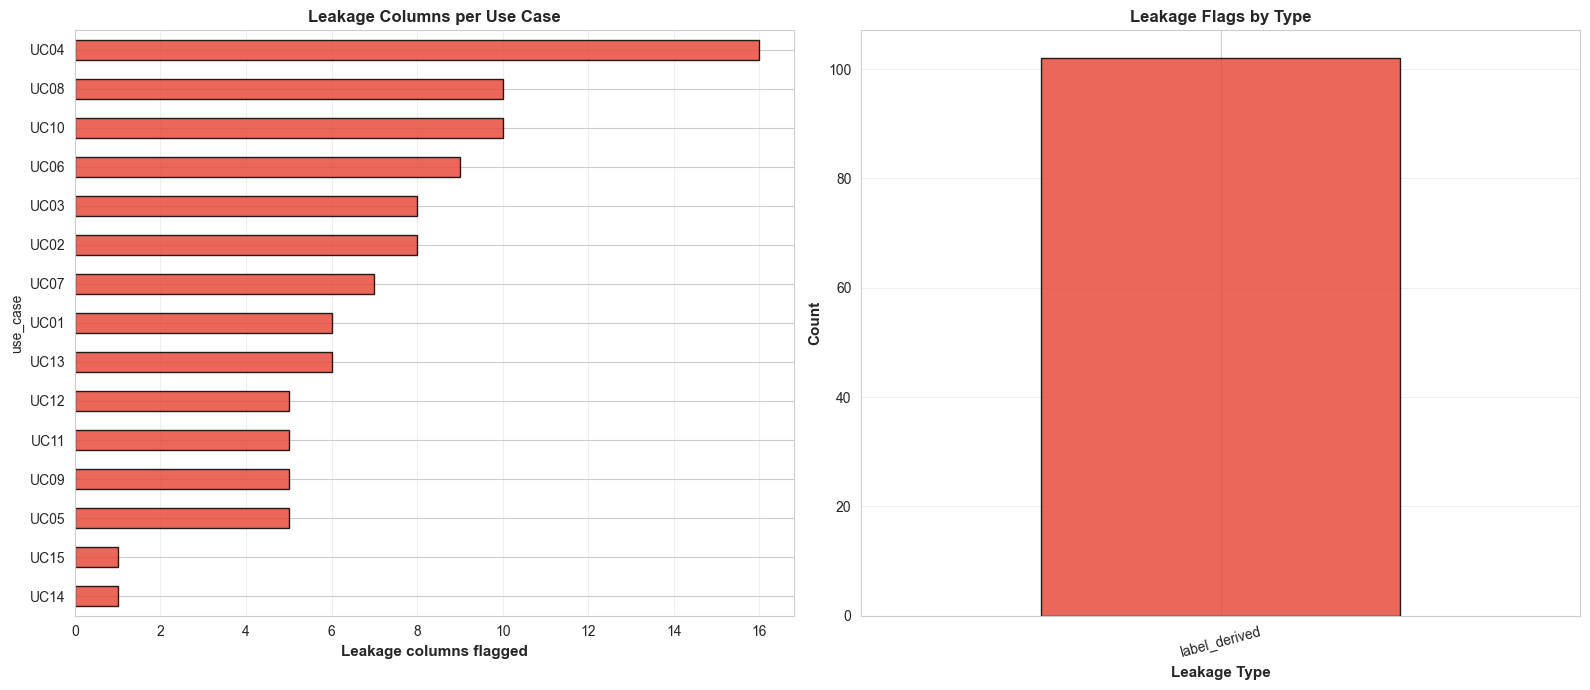

Saved: 04_leakage_flags.png


In [6]:
if len(leakage_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    uc_counts = leakage_df.groupby('use_case')['column'].count().sort_values(ascending=True)
    uc_counts.plot(kind='barh', ax=axes[0], color='#e74c3c', alpha=0.85, edgecolor='black')
    axes[0].set_xlabel('Leakage columns flagged', fontsize=11, fontweight='bold')
    axes[0].set_title('Leakage Columns per Use Case', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    type_counts = leakage_df['leakage_type'].value_counts()
    type_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12'], alpha=0.85, edgecolor='black')
    axes[1].set_xlabel('Leakage Type', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[1].set_title('Leakage Flags by Type', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(FS_DIR / '04_leakage_flags.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: 04_leakage_flags.png")

## 7. Summary

In [7]:
print("=" * 55)
print("LEAKAGE DETECTION COMPLETE")
print("=" * 55)
print(f"Total leakage flags  : {len(leakage_df)}")
print(f"  label_derived      : {(leakage_df['leakage_type']=='label_derived').sum() if len(leakage_df) > 0 else 0}")
print(f"  high_correlation   : {(leakage_df['leakage_type']=='high_correlation').sum() if len(leakage_df) > 0 else 0}")
print()
print("Columns flagged for drop:")
drop_df = leakage_df[leakage_df['action']=='drop']
for _, row in drop_df.iterrows():
    print(f"  {row['use_case']:<5} {row['column']:<50} {row['leakage_type']}")
print()
print("Columns flagged for investigation:")
inv_df = leakage_df[leakage_df['action']=='investigate']
for _, row in inv_df.iterrows():
    print(f"  {row['use_case']:<5} {row['column']:<50} {row['leakage_reason']}")
print()
print("Next: 05_feature_reduction.ipynb")

LEAKAGE DETECTION COMPLETE
Total leakage flags  : 102
  label_derived      : 102
  high_correlation   : 0

Columns flagged for drop:
  UC01  clinical_significance_simple                       label_derived
  UC01  clinvar_pathogenicity_class                        label_derived
  UC01  protein_impact_category                            label_derived
  UC01  x_linked_risk_modifier                             label_derived
  UC01  inheritance_pathogenicity_modifier                 label_derived
  UC01  is_cancer_relevant                                 label_derived
  UC02  clinical_significance_simple                       label_derived
  UC02  disease_enriched                                   label_derived
  UC02  primary_disease                                    label_derived
  UC02  disease_name_enriched                              label_derived
  UC02  variant_disease_link_quality                       label_derived
  UC02  disease_complexity                                 label